# Regresion: pronostico de ingresos semanales

## Objetivo

Esta libreta entrena un modelo de **regresion** para pronosticar ingresos semanales por sucursal.

Se comparan dos enfoques:

- **Regresion lineal**: modelo simple y explicable; sirve como linea base.
- **Random Forest Regressor**: modelo no lineal; captura patrones por semana, ocupacion y ticket promedio.

In [1]:
from pathlib import Path
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2

sns.set_theme(style="whitegrid")

SERVER_ROOT = Path.cwd()
if SERVER_ROOT.name == "notebooks":
    SERVER_ROOT = SERVER_ROOT.parents[1]
elif SERVER_ROOT.name == "ml":
    SERVER_ROOT = SERVER_ROOT.parent

ARTIFACT_DIR = SERVER_ROOT / "ml" / "artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

def load_env(path):
    env = {}
    for raw in Path(path).read_text(encoding="utf-8").splitlines():
        line = raw.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, value = line.split("=", 1)
        env[key.strip()] = value.strip().strip('"').strip("'")
    return env

env = {**load_env(SERVER_ROOT / ".env"), **os.environ}

def connect():
    conn = psycopg2.connect(
        host=env.get("DB_HOST", "localhost"),
        port=int(env.get("DB_PORT", 5432)),
        user=env.get("DB_USER", "postgres"),
        password=env.get("DB_PASSWORD", ""),
        dbname=env.get("DB_NAME", "db_barberia"),
    )
    with conn.cursor() as cur:
        cur.execute("SET search_path TO core, catalogo, admin, public")
    return conn

conn = connect()
df = pd.read_sql_query("SELECT * FROM analitica.ml_citas_dataset ORDER BY id", conn)
df["fecha"] = pd.to_datetime(df["fecha"])
df["hora"] = pd.to_datetime(df["hora"].astype(str), format="%H:%M:%S", errors="coerce").dt.hour
df.head()

C:\Users\Javi\AppData\Local\Temp\ipykernel_4340\267030489.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query("SELECT * FROM analitica.ml_citas_dataset ORDER BY id", conn)


,id,cliente_ref,cliente_nombre,local_id,local_nombre,servicio_id,servicio_nombre,barbero_id,barbero_nombre,fecha,...,monto_pagado,estado_cita,recordatorio_enviado,frecuencia_cliente,recencia_dias,gasto_total_cliente,no_show_rate_cliente,canal,seed_run_id,created_at
0,1,20,Eduardo Reyes,1,Barbería Carlyn,12,Paquete 2 - Ritual Caballero,35,Luis Hernández,2026-05-22,...,319.15,asistio,True,3,12,889.09,0.0794,walk-in,20260722084715,2026-07-22 08:47:15.164613
1,2,204,Emiliano Cruz,1,Barbería Carlyn,11,Paquete 1 - Corte First Class,34,Carlos Méndez,2026-06-16,...,246.26,asistio,False,4,58,584.85,0.0876,telefono,20260722084715,2026-07-22 08:47:15.164613
2,3,159,Pablo Lopez,1,Barbería Carlyn,12,Paquete 2 - Ritual Caballero,34,Carlos Méndez,2026-07-16,...,313.55,asistio,True,8,23,1075.99,0.0815,web,20260722084715,2026-07-22 08:47:15.164613
3,4,106,Sergio Aguilar,1,Barbería Carlyn,12,Paquete 2 - Ritual Caballero,34,Carlos Méndez,2026-07-13,...,315.20,asistio,False,2,66,660.94,0.2215,web,20260722084715,2026-07-22 08:47:15.164613
4,5,118,Miguel Moreno,1,Barbería Carlyn,13,Paquete 3 - Premium Black,34,Carlos Méndez,2026-02-19,...,376.15,asistio,True,3,58,429.97,0.3574,walk-in,20260722084715,2026-07-22 08:47:15.164613


## 1. Agregacion semanal

El modelo de ingresos no usa cada cita individual como objetivo. Primero agrupamos las citas completadas por sucursal y semana.

In [2]:
history = df[(df["estado_cita"] == "asistio") & (df["monto_pagado"] > 0)].copy()

weekly = (
    history.groupby(["local_id", "local_nombre", "semana"], as_index=False)
    .agg(
        ingreso=("monto_pagado", "sum"),
        citas=("id", "count"),
        clientes=("cliente_ref", "nunique"),
        ticket=("monto_pagado", "mean"),
        duracion_promedio=("duracion", "mean"),
    )
    .sort_values(["local_id", "semana"])
)

weekly["ocupacion"] = np.clip(weekly["citas"] / 95.0, 0.15, 1.0)
weekly.head()

,local_id,local_nombre,semana,ingreso,citas,clientes,ticket,duracion_promedio,ocupacion
0,1,Barbería Carlyn,1,9603.78,29,29,331.164828,78.103448,0.305263
1,1,Barbería Carlyn,2,8394.21,26,25,322.854231,77.884615,0.273684
2,1,Barbería Carlyn,3,7125.21,20,20,356.260500,81.750000,0.210526
3,1,Barbería Carlyn,4,10979.99,34,32,322.940882,77.205882,0.357895
4,1,Barbería Carlyn,5,5873.09,18,18,326.282778,77.500000,0.189474


## 2. Variables del modelo

La variable objetivo es `ingreso`. Las variables explicativas representan volumen, mezcla comercial y ocupacion.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

features = ["local_id", "semana", "citas", "clientes", "ticket", "duracion_promedio", "ocupacion"]
X = weekly[features]
y = weekly["ingreso"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

## 3. Modelo base: Regresion lineal

La regresion lineal asume una relacion proporcional entre las variables y el ingreso. Es facil de explicar, pero puede quedarse corta si hay patrones no lineales.

In [4]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

linear_metrics = {
    "MAE": mean_absolute_error(y_test, linear_pred),
    "RMSE": mean_squared_error(y_test, linear_pred) ** 0.5,
    "R2": r2_score(y_test, linear_pred),
}

pd.DataFrame([linear_metrics], index=["Regresion lineal"])

,MAE,RMSE,R2
Regresion lineal,76.634846,95.929937,0.997522


## 4. Modelo principal: Random Forest Regressor

Random Forest Regressor combina muchos arboles para capturar relaciones no lineales: por ejemplo, semanas con mayor demanda, tickets mas altos y ocupacion.

In [5]:
rf_regressor = RandomForestRegressor(
    n_estimators=180,
    max_depth=8,
    min_samples_leaf=3,
    random_state=42,
)

rf_regressor.fit(X_train, y_train)
rf_pred = rf_regressor.predict(X_test)

rf_metrics = {
    "MAE": mean_absolute_error(y_test, rf_pred),
    "RMSE": mean_squared_error(y_test, rf_pred) ** 0.5,
    "R2": r2_score(y_test, rf_pred),
}

pd.DataFrame([linear_metrics, rf_metrics], index=["Regresion lineal", "Random Forest Regressor"])

,MAE,RMSE,R2
Regresion lineal,76.634846,95.929937,0.997522
Random Forest Regressor,805.859078,1046.238218,0.705245


## 5. Comparacion visual: real vs predicho

Mientras mas cerca esten los puntos de la linea diagonal, mejor es el ajuste.

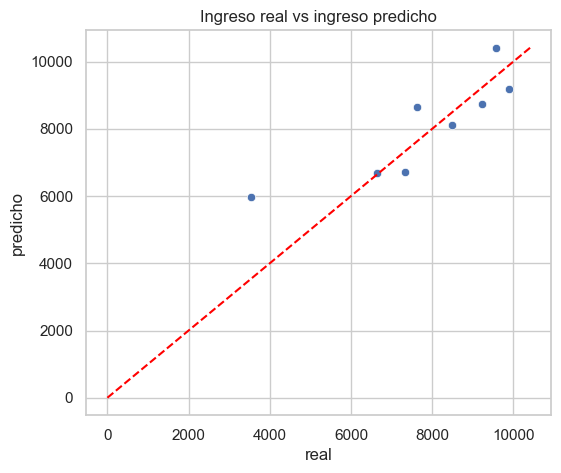

In [6]:
comparison = pd.DataFrame({"real": y_test, "predicho": rf_pred})

plt.figure(figsize=(6, 5))
sns.scatterplot(data=comparison, x="real", y="predicho")
limit = max(comparison["real"].max(), comparison["predicho"].max())
plt.plot([0, limit], [0, limit], color="red", linestyle="--")
plt.title("Ingreso real vs ingreso predicho")
plt.show()

## 6. Importancia de variables

Esto permite explicar que variables pesan mas en el pronostico.

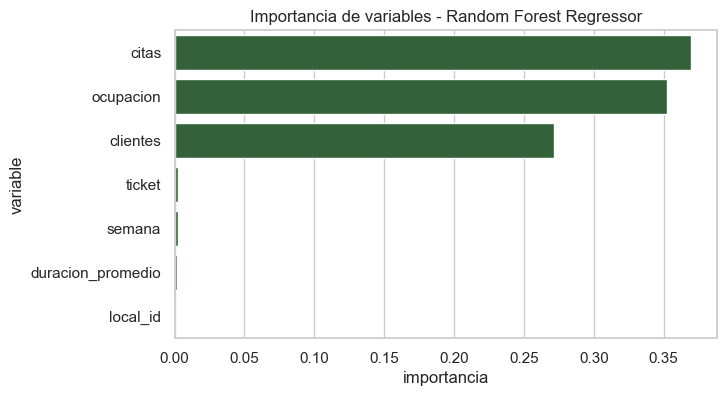

,variable,importancia
2,citas,0.369626
6,ocupacion,0.352036
3,clientes,0.271482
4,ticket,0.002375
1,semana,0.002347
5,duracion_promedio,0.002135
0,local_id,0.000000


In [7]:
importance = pd.DataFrame({
    "variable": features,
    "importancia": rf_regressor.feature_importances_,
}).sort_values("importancia", ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(data=importance, x="importancia", y="variable", color="#2B6A35")
plt.title("Importancia de variables - Random Forest Regressor")
plt.show()

importance

## 7. Pronostico de las siguientes semanas

Construimos escenarios futuros tomando promedios recientes por sucursal y proyectando las siguientes 4 semanas.

In [8]:
from datetime import date, timedelta

future_rows = []
start = date.today() + timedelta(days=(7 - date.today().weekday()))

for (local_id, local_nombre), group in weekly.groupby(["local_id", "local_nombre"]):
    base = group.tail(4).mean(numeric_only=True)
    for i in range(4):
        week_start = start + timedelta(days=i * 7)
        future_rows.append({
            "local_id": local_id,
            "local_nombre": local_nombre,
            "semana": int(week_start.isocalendar().week),
            "fecha_inicio": week_start,
            "citas": max(15, base["citas"] * (1 + 0.04 * i)),
            "clientes": max(10, base["clientes"] * (1 + 0.03 * i)),
            "ticket": max(120, base["ticket"] * (1 + 0.015 * i)),
            "duracion_promedio": base["duracion_promedio"],
            "ocupacion": float(np.clip(base["ocupacion"] + 0.03 * i, 0.20, 0.96)),
        })

future = pd.DataFrame(future_rows)
future["ingreso_proyectado"] = rf_regressor.predict(future[features])
future[["local_nombre", "semana", "fecha_inicio", "ingreso_proyectado", "ticket", "ocupacion"]]

,local_nombre,semana,fecha_inicio,ingreso_proyectado,ticket,ocupacion
0,Barbería Carlyn,31,2026-07-27,6256.462242,343.672743,0.203289
1,Barbería Carlyn,32,2026-08-03,6515.837188,348.827834,0.233289
2,Barbería Carlyn,33,2026-08-10,7366.929565,353.982925,0.263289
3,Barbería Carlyn,34,2026-08-17,7430.848853,359.138016,0.293289


## 8. Guardado del modelo

Guardamos el modelo de regresion para usarlo desde procesos automatizados.

In [9]:
artifact_path = ARTIFACT_DIR / "notebook_income_random_forest_regressor.joblib"
joblib.dump(rf_regressor, artifact_path)
artifact_path

WindowsPath('C:/Users/Javi/Desktop/Frameworks/React/Barberia Carlyn/barberia-carlyn-server/ml/artifacts/notebook_income_random_forest_regressor.joblib')